# **YOLO**

In [56]:
!pip install roboflow

from roboflow import Roboflow

In [57]:
# Step 1: Connect to Roboflow using your API key
rf = Roboflow(api_key="WCP0R2VANnlSLDyjm0eo")

In [58]:
# Step 2: Access your workspace and project
project = rf.workspace("tanzeela-1mxls").project("traffic_management-ivfyq")

loading Roboflow workspace...
loading Roboflow project...


In [59]:
# Step 3: Download the dataset in YOLOv5 format
dataset = project.version(1).download("yolov5")


In [60]:

print(dataset.location)


/content/traffic_management-1


In [61]:
!ls /content/traffic_management-1/


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [62]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 17483, done.
remote: Total 17483 (delta 0), reused 0 (delta 0), pack-reused 17483 (from 1)
Receiving objects: 100% (17483/17483), 16.58 MiB | 10.58 MiB/s, done.
Resolving deltas: 100% (11991/11991), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.3 MB/s eta 0:00:00


In [63]:
%cat {dataset.location}/data.yaml

names:
- accident_ambulance
- accident_autorickshaw
- accident_bicycle
- accident_bus
- accident_car
- accident_fire_truck
- accident_motorcyle
- accident_truck
- ambulance
- autorickshaw
- bicycle
- bus
- car
- fire_truck
- motorcycle
- truck
nc: 16
roboflow:
  license: CC BY 4.0
  project: traffic_management-ivfyq
  url: https://universe.roboflow.com/tanzeela-1mxls/traffic_management-ivfyq/dataset/1
  version: 1
  workspace: tanzeela-1mxls
test: ../test/images
train: traffic_management-1/train/images
val: traffic_management-1/valid/images


In [64]:
import yaml

with open("/content/traffic_management-1/data.yaml", 'r') as f:
    data = yaml.safe_load(f)

num_classes = data['nc']
class_names = data['names']

print(f"Number of classes: {num_classes}")
print("Class names:", class_names)
#extract classs name & no of classes

Number of classes: 16
Class names: ['accident_ambulance', 'accident_autorickshaw', 'accident_bicycle', 'accident_bus', 'accident_car', 'accident_fire_truck', 'accident_motorcyle', 'accident_truck', 'ambulance', 'autorickshaw', 'bicycle', 'bus', 'car', 'fire_truck', 'motorcycle', 'truck']


In [ ]:
%cat /content/yolov5/models/yolov5s.yaml

# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Parameters
nc: 80 # number of classes
depth_multiple: 0.33 # model depth multiple
width_multiple: 0.50 # layer channel multiple
anchors:
  - [10, 13, 16, 30, 33, 23] # P3/8
  - [30, 61, 62, 45, 59, 119] # P4/16
  - [116, 90, 156, 198, 373, 326] # P5/32

# YOLOv5 v6.0 backbone
backbone:
  # [from, number, module, args]
  [
    [-1, 1, Conv, [64, 6, 2, 2]], # 0-P1/2
    [-1, 1, Conv, [128, 3, 2]], # 1-P2/4
    [-1, 3, C3, [128]],
    [-1, 1, Conv, [256, 3, 2]], # 3-P3/8
    [-1, 6, C3, [256]],
    [-1, 1, Conv, [512, 3, 2]], # 5-P4/16
    [-1, 9, C3, [512]],
    [-1, 1, Conv, [1024, 3, 2]], # 7-P5/32
    [-1, 3, C3, [1024]],
    [-1, 1, SPPF, [1024, 5]], # 9
  ]

# YOLOv5 v6.0 head
head: [
    [-1, 1, Conv, [512, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, "nearest"]],
    [[-1, 6], 1, Concat, [1]], # cat backbone P4
    [-1, 3, C3, [512, False]], # 13

    [-1, 1, Conv, [256, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, 

In [ ]:
%%writefile /content/yolov5/models/custom_yolov5s.yaml

# Parameters
nc: {num_classes} # number of classes
depth_multiple: 0.33 # model depth multiple
width_multiple: 0.50 # layer channel multiple
anchors:
  - [10, 13, 16, 30, 33, 23] # P3/8
  - [30, 61, 62, 45, 59, 119] # P4/16
  - [116, 90, 156, 198, 373, 326] # P5/32

# YOLOv5 v6.0 backbone
backbone:
  # [from, number, module, args]
  [
    [-1, 1, Conv, [64, 6, 2, 2]], # 0-P1/2
    [-1, 1, Conv, [128, 3, 2]], # 1-P2/4
    [-1, 3, C3, [128]],
    [-1, 1, Conv, [256, 3, 2]], # 3-P3/8
    [-1, 6, C3, [256]],
    [-1, 1, Conv, [512, 3, 2]], # 5-P4/16
    [-1, 9, C3, [512]],
    [-1, 1, Conv, [1024, 3, 2]], # 7-P5/32
    [-1, 3, C3, [1024]],
    [-1, 1, SPPF, [1024, 5]], # 9
  ]

# YOLOv5 v6.0 head
head: [
    [-1, 1, Conv, [512, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, "nearest"]],
    [[-1, 6], 1, Concat, [1]], # cat backbone P4
    [-1, 3, C3, [512, False]], # 13

    [-1, 1, Conv, [256, 1, 1]],
    [-1, 1, nn.Upsample, [None, 2, "nearest"]],
    [[-1, 4], 1, Concat, [1]], # cat backbone P3
    [-1, 3, C3, [256, False]], # 17 (P3/8-small)

    [-1, 1, Conv, [256, 3, 2]],
    [[-1, 14], 1, Concat, [1]], # cat head P4
    [-1, 3, C3, [512, False]], # 20 (P4/16-medium)

    [-1, 1, Conv, [512, 3, 2]],
    [[-1, 10], 1, Concat, [1]], # cat head P5
    [-1, 3, C3, [1024, False]], # 23 (P5/32-large)

    [[17, 20, 23], 1, Detect, [nc, anchors]], # Detect(P3, P4, P5)
  ]

Writing /content/yolov5/models/custom_yolov5s.yaml


In [ ]:
dataset.location

'/content/traffic_management-1'

# For model **training**

In [ ]:
%%time
%cd /content/yolov5/
!python train.py --img 640 --batch 16 --epochs 20 --data /content/traffic_management-1/data.yaml --cfg ./models/custom_yolov5s.yaml --weights yolov5s.pt --name yolov5s_results --cache


Streaming output truncated to the last 5000 lines.
      17/19      4.53G    0.02566    0.02664    0.01204        134        640:  31% 290/923 [02:01<04:09,  2.54it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      4.53G    0.02565    0.02663    0.01203        107        640:  32% 291/923 [02:02<05:42,  1.85it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      4.53G    0.02564    0.02663    0.01201         93        640:  32% 292/923 [02:02<04:53,  2.15it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      4.53G    0.025

# **Best model save**

In [ ]:
from google.colab import files
files.download('/content/yolov5/runs/train/yolov5s_results5/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Use Trained Model**

In [65]:
from google.colab import files
uploaded = files.upload()

Saving best.pt to best.pt


# **For performance**

In [68]:
from IPython.display import Image
Image(filename='/content/yolov5/runs/train/yolov5s_results5/results.png')


FileNotFoundError: [Errno 2] No such file or directory: '/content/yolov5/runs/train/yolov5s_results5/results.png'

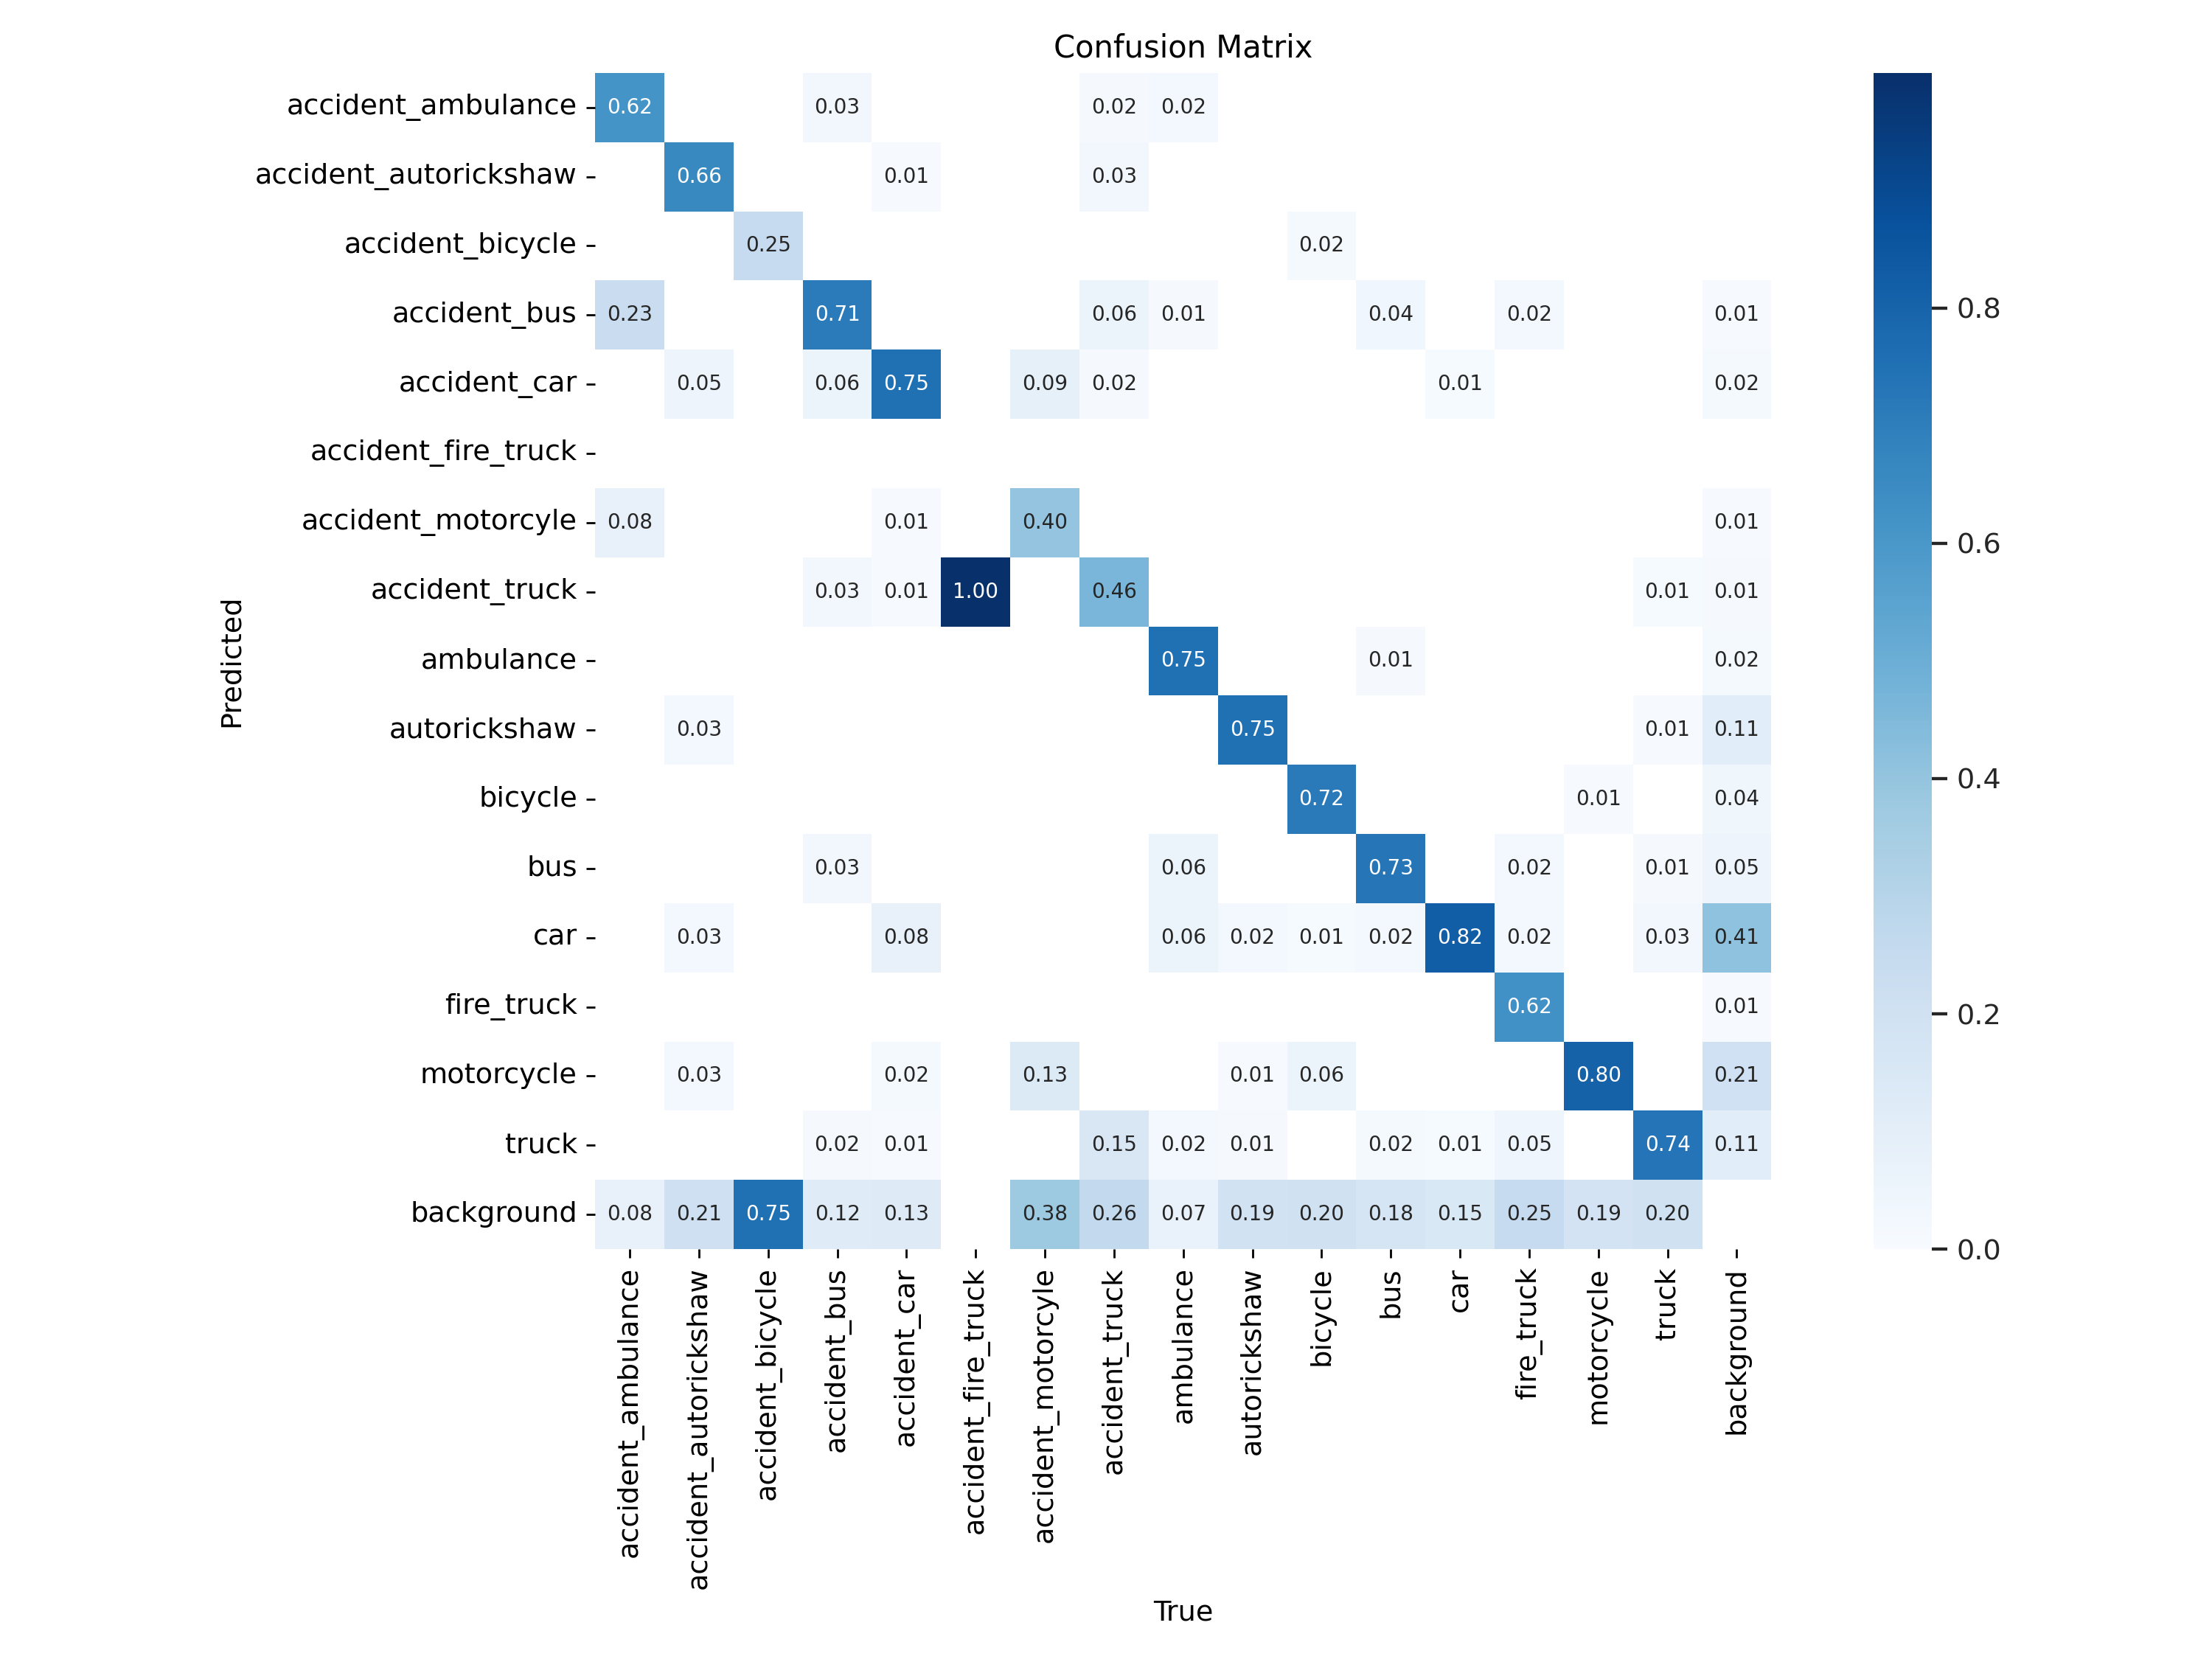

In [ ]:
from IPython.display import Image
Image(filename='/content/yolov5/runs/train/yolov5s_results5/confusion_matrix.png')

# **For prediction**

In [ ]:
!python detect.py --weights runs/train/yolov5s_results5/weights/best.pt --img 640 --source /content/traffic_management-1/test/images/


detect: weights=['runs/train/yolov5s_results5/weights/best.pt'], source=/content/traffic_management-1/test/images/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-419-gcd44191c Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
custom_YOLOv5s summary: 157 layers, 7053277 parameters, 0 gradients, 15.9 GFLOPs
image 1/569 /content/traffic_management-1/test/images/10_jpeg_jpg.rf.31d5f665330b62b645ddd8179004787b.jpg: 640x640 2 autorickshaws, 1 bicycle, 11.6ms
image 2/569 /content/traffic_management-1/test/images/111_jpeg_jpg.rf.c5c3076e89a4cebb05e5353c88180781.jpg: 640x640 1 t

# **check prediction accuracy**

In [ ]:
import torch
# Load the best model
!python detect.py --weights runs/train/yolov5s_results5/weights/best.pt --img 640 --source /content/traffic_management-1/test/images/


detect: weights=['runs/train/yolov5s_results5/weights/best.pt'], source=/content/traffic_management-1/test/images/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-419-gcd44191c Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
custom_YOLOv5s summary: 157 layers, 7053277 parameters, 0 gradients, 15.9 GFLOPs
image 1/569 /content/traffic_management-1/test/images/10_jpeg_jpg.rf.31d5f665330b62b645ddd8179004787b.jpg: 640x640 2 autorickshaws, 1 bicycle, 11.6ms
image 2/569 /content/traffic_management-1/test/images/111_jpeg_jpg.rf.c5c3076e89a4cebb05e5353c88180781.jpg: 640x640 1 t

In [1]:
!pip install roboflow

from roboflow import Roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 7.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


# **Faster R-CNN**

In [2]:
rf = Roboflow(api_key="WCP0R2VANnlSLDyjm0eo")

In [3]:
project = rf.workspace("tanzeela-1mxls").project("traffic_management-ivfyq")

loading Roboflow workspace...
loading Roboflow project...


In [4]:
dataset = project.version(1).download("yolov5")


Extracting Dataset Version Zip to traffic_management-1 in yolov5pytorch:: 100%|██████████| 32836/32836 [00:08<00:00, 4017.44it/s]


In [7]:
import os
from PIL import Image
import xml.etree.ElementTree as ET
from xml.dom.minidom import parseString

# Update this path to point to your YOLO dataset folder
images_path = "/content/traffic_management-1/train/images"
labels_path = "/content/traffic_management-1/train/labels"
annotations_path = "/content/traffic_management-1/train/annotations"

# Class list (update based on your dataset classes)
classes = ['accident_ambulance','accident_autorickshaw','accident_bicycle','accident_bus','accident_car','accident_fire_truck','accident_motorcyle','accident_truck','ambulance','autorickshaw','bicycle','bus','car','fire_truck','motorcyle','truck']



os.makedirs(annotations_path, exist_ok=True)

def convert_yolo_to_voc(img_filename):
    image = Image.open(os.path.join(images_path, img_filename))
    width, height = image.size
    base_name = os.path.splitext(img_filename)[0]
    label_file = os.path.join(labels_path, base_name + ".txt")

    annotation = ET.Element("annotation")
    ET.SubElement(annotation, "folder").text = "images"
    ET.SubElement(annotation, "filename").text = img_filename

    size = ET.SubElement(annotation, "size")
    ET.SubElement(size, "width").text = str(width)
    ET.SubElement(size, "height").text = str(height)
    ET.SubElement(size, "depth").text = "3"

    ET.SubElement(annotation, "segmented").text = "0"

    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id, x_center, y_center, w, h = map(float, parts)

                xmin = int((x_center - w / 2) * width)
                ymin = int((y_center - h / 2) * height)
                xmax = int((x_center + w / 2) * width)
                ymax = int((y_center + h / 2) * height)

                obj = ET.SubElement(annotation, "object")
                ET.SubElement(obj, "name").text = classes[int(class_id)]
                ET.SubElement(obj, "pose").text = "Unspecified"
                ET.SubElement(obj, "truncated").text = "0"
                ET.SubElement(obj, "difficult").text = "0"

                bndbox = ET.SubElement(obj, "bndbox")
                ET.SubElement(bndbox, "xmin").text = str(xmin)
                ET.SubElement(bndbox, "ymin").text = str(ymin)
                ET.SubElement(bndbox, "xmax").text = str(xmax)
                ET.SubElement(bndbox, "ymax").text = str(ymax)

    xml_str = ET.tostring(annotation)
    pretty_xml = parseString(xml_str).toprettyxml(indent="  ")
    with open(os.path.join(annotations_path, base_name + ".xml"), "w") as f:
        f.write(pretty_xml)

# Convert all images in the train folder
for img_file in os.listdir(images_path):
    if img_file.endswith(".jpg") or img_file.endswith(".png"):
        convert_yolo_to_voc(img_file)

print("✅ Conversion complete for train dataset!")


✅ Conversion complete for train dataset!


In [8]:
import os
import torch
from PIL import Image
import xml.etree.ElementTree as ET

class PascalVOCDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, annotations_dir, classes, transforms=None):
        self.images_dir = images_dir
        self.annotations_dir = annotations_dir
        self.transforms = transforms
        self.classes = classes

        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(".jpg") or f.endswith(".png")]

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        annotation_path = os.path.join(self.annotations_dir, os.path.splitext(img_name)[0] + ".xml")

        img = Image.open(img_path).convert("RGB")
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        boxes = []
        labels = []

        for obj in root.findall("object"):
            label = obj.find("name").text
            labels.append(self.classes.index(label))

            bndbox = obj.find("bndbox")
            xmin = int(bndbox.find("xmin").text)
            ymin = int(bndbox.find("ymin").text)
            xmax = int(bndbox.find("xmax").text)
            ymax = int(bndbox.find("ymax").text)
            boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.image_files)


In [76]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import torch
import os
import xml.etree.ElementTree as ET
from PIL import Image

# Assuming PascalVOCDataset class is defined as in the user's code

# Define your classes
classes = ["__background__", 'accident_ambulance','accident_autorickshaw','accident_bicycle','accident_bus','accident_car','accident_fire_truck','accident_motorcyle','accident_truck','ambulance','autorickshaw','bicycle','bus','car','fire_truck','motorcyle','truck']  # Always put background at index 0

# Define paths
images_dir="/content/traffic_management-1/train/images"
annotations_dir="/content/traffic_management-1/train/annotations"

# --- Start of added code ---

# Filter out images with no annotations
valid_image_files = []
for img_file in os.listdir(images_dir):
    if img_file.endswith(".jpg") or img_file.endswith(".png"):
        annotation_path = os.path.join(annotations_dir, os.path.splitext(img_file)[0] + ".xml")
        if os.path.exists(annotation_path):
            tree = ET.parse(annotation_path)
            root = tree.getroot()
            # Check if there are any 'object' elements in the XML
            if root.findall("object"):
                valid_image_files.append(img_file)
        else:
             # Optionally print a warning if an annotation file is missing for an image
             print(f"Warning: Annotation file missing for image: {img_file}")

# Create a subset dataset with only valid images
class FilteredPascalVOCDataset(PascalVOCDataset):
    def __init__(self, images_dir, annotations_dir, classes, valid_image_files, transforms=None):
        super().__init__(images_dir, annotations_dir, classes, transforms)
        self.image_files = valid_image_files # Use the filtered list

# Load the filtered dataset
train_dataset = FilteredPascalVOCDataset(
    images_dir=images_dir,
    annotations_dir=annotations_dir,
    classes=classes,
    valid_image_files=valid_image_files,
    transforms=ToTensor()
)

# --- End of added code ---


train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Load pretrained Faster R-CNN and update head
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = len(classes)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

# ... (previous training loop code)

num_epochs = 10
model.train()
for epoch in range(num_epochs):
    for imgs, targets in train_loader:
        # Check the device of the images and targets
        print(f"Images device: {imgs[0].device}")
        print(f"Targets device: {targets[0]['boxes'].device}")

        imgs = list(img.to(device) for img in imgs)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Check the device after moving to the specified device
        print(f"Images device after moving: {imgs[0].device}")
        print(f"Targets device after moving: {targets[0]['boxes'].device}")


        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {losses.item():.4f}")

print("✅ Training complete!")


Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images device: cpu
Targets device: cpu
Images device after moving: cuda:0
Targets device after moving: cuda:0
Images dev

In [77]:
torch.save(model.state_dict(), "fasterrcnn_model.pth")


In [78]:
from google.colab import files
files.download("fasterrcnn_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
!pip install torchmetrics


In [79]:
FastRCNNPredictor(in_features, num_classes)


FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=17, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=68, bias=True)
)

In [88]:
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import time

# Switch to eval mode
model.eval()
metric = MeanAveragePrecision()
start = time.time()

with torch.no_grad():
    for images, targets in train_loader:  # Use test_loader if you have test data
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        # Prepare predictions and ground truths in the expected format
        for output, target in zip(outputs, targets):
            pred = {
                "boxes": output["boxes"].cpu(),
                "scores": output["scores"].cpu(),
                "labels": output["labels"].cpu()
            }
            gt = {
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            }
            metric.update([pred], [gt])

end = time.time()
results = metric.compute()

print(f"mAP: {results['map']:.4f}")
print(f"Precision: {results['map_50']:.4f}")
print(f"Recall: {results['mar_100']:.4f}")
f1_score = 2 * (results['map_50'] * results['mar_100']) / (results['map_50'] + results['mar_100'] + 1e-6)
print(f"F1 Score: {f1_score:.4f}")
print(f"Inference Speed (FPS): {len(train_loader.dataset) / (end - start):.2f}")


mAP: 0.5064
Precision: 0.8928
Recall: 0.5753
F1 Score: 0.6997
Inference Speed (FPS): 10.54


# Esemble **model**

In [92]:
from torchvision.ops import nms

all_ensemble_preds_formatted = []

with torch.no_grad():
    for rcnn_pred, yolo_pred in zip(all_rcnn_preds_formatted, all_yolo_preds_formatted):
        # Combine predictions
        combined_boxes = torch.cat([rcnn_pred['boxes'], yolo_pred['boxes']], dim=0)
        combined_scores = torch.cat([rcnn_pred['scores'], yolo_pred['scores']], dim=0)
        combined_labels = torch.cat([rcnn_pred['labels'], yolo_pred['labels']], dim=0)

        # Apply NMS on combined predictions
        keep_indices = nms(combined_boxes, combined_scores, iou_threshold=0.5)
        final_boxes = combined_boxes[keep_indices]
        final_scores = combined_scores[keep_indices]
        final_labels = combined_labels[keep_indices]

        all_ensemble_preds_formatted.append({
            'boxes': final_boxes,
            'scores': final_scores,
            'labels': final_labels
        })


In [93]:
metric_ensemble = MeanAveragePrecision()
metric_ensemble.update(all_ensemble_preds_formatted, all_rcnn_targets_formatted)
ensemble_map_results = metric_ensemble.compute()

print("\nEnsemble Metrics:")
print(ensemble_map_results)



Ensemble Metrics:
{'map': tensor(-1.), 'map_50': tensor(-1.), 'map_75': tensor(-1.), 'map_small': tensor(-1.), 'map_medium': tensor(-1.), 'map_large': tensor(-1.), 'mar_1': tensor(-1.), 'mar_10': tensor(-1.), 'mar_100': tensor(-1.), 'mar_small': tensor(-1.), 'mar_medium': tensor(-1.), 'mar_large': tensor(-1.), 'classes': tensor([], dtype=torch.int32)}
